In [33]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from collections import Counter



In [11]:
#exploring data

#reading data
file_path = "../data/Divvy_Trips_2020_Q1_csv_version.csv"
data = pd.read_csv(file_path)

In [3]:
# red text: \033[31m  \033[0m
print("\033[31mcolumns\033[0m")
print(data.columns)
print("\n\033[31mdata type\033[0m\n")
print(data.dtypes)

columns
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'ride_length', 'day_of_week'],
      dtype='object')

data type

ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id        int64
end_station_name       object
end_station_id        float64
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
ride_length            object
day_of_week             int64
dtype: object


In [4]:
# Display the first 5 rows
print(data.head())

            ride_id rideable_type       started_at         ended_at  \
0  EACB19130B0CDA4A   docked_bike  1/21/2020 20:06  1/21/2020 20:14   
1  8FED874C809DC021   docked_bike  1/30/2020 14:22  1/30/2020 14:26   
2  789F3C21E472CA96   docked_bike   1/9/2020 19:29   1/9/2020 19:32   
3  C9A388DAC6ABF313   docked_bike   1/6/2020 16:17   1/6/2020 16:25   
4  943BC3CBECCFD662   docked_bike   1/30/2020 8:37   1/30/2020 8:42   

         start_station_name  start_station_id                end_station_name  \
0  Western Ave & Leland Ave               239           Clark St & Leland Ave   
1   Clark St & Montrose Ave               234  Southport Ave & Irving Park Rd   
2    Broadway & Belmont Ave               296        Wilton Ave & Belmont Ave   
3    Clark St & Randolph St                51        Fairbanks Ct & Grand Ave   
4      Clinton St & Lake St                66           Wells St & Hubbard St   

   end_station_id  start_lat  start_lng  end_lat  end_lng member_casual  \
0          

In [5]:
# validacion de datos
trafico_dias = data.day_of_week
print("valores nulos\n")
print(trafico_dias.isnull().sum())
print("valores  nan\n")
print(trafico_dias.isna().sum())
print("tipos de datos")
print(trafico_dias.dtype)
print("datos no validos")
noValid = trafico_dias.apply(lambda x: isinstance(x, int)) ## valida el tipo de dato
print(list(filter(lambda x: x is False, noValid)))

# no hay datos atipicos :)


valores nulos

0
valores  nan

0
tipos de datos
int64
datos no validos
[]


Text(0, 0.5, 'Numero de bikers')

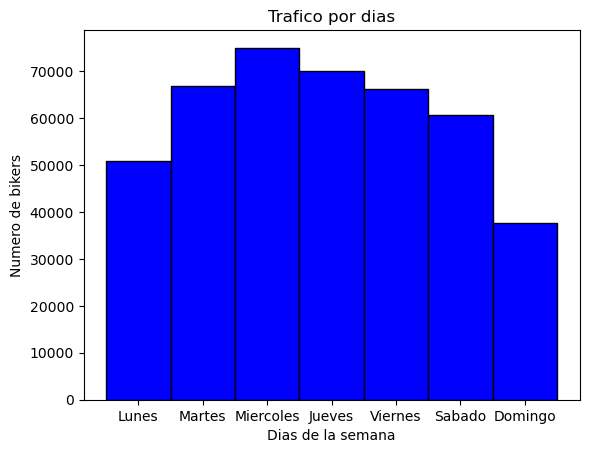

In [6]:
# visualizacion de dias mas concurridos -> respondiendo a: ¿Que dias hay mas flujo de bikers?
conteo, bins, patches = plt.hist(trafico_dias, bins=7, color="blue", edgecolor="black")

# Crear etiquetas personalizadas para cada bin
etiquetas = ["Lunes", "Martes", "Miercoles", "Jueves", "Viernes", "Sabado", "Domingo"]
# Colocar etiquetas en el eje X
plt.xticks([(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)], etiquetas)

plt.title("Trafico por dias")
plt.xlabel("Dias de la semana")
plt.ylabel("Numero de bikers")

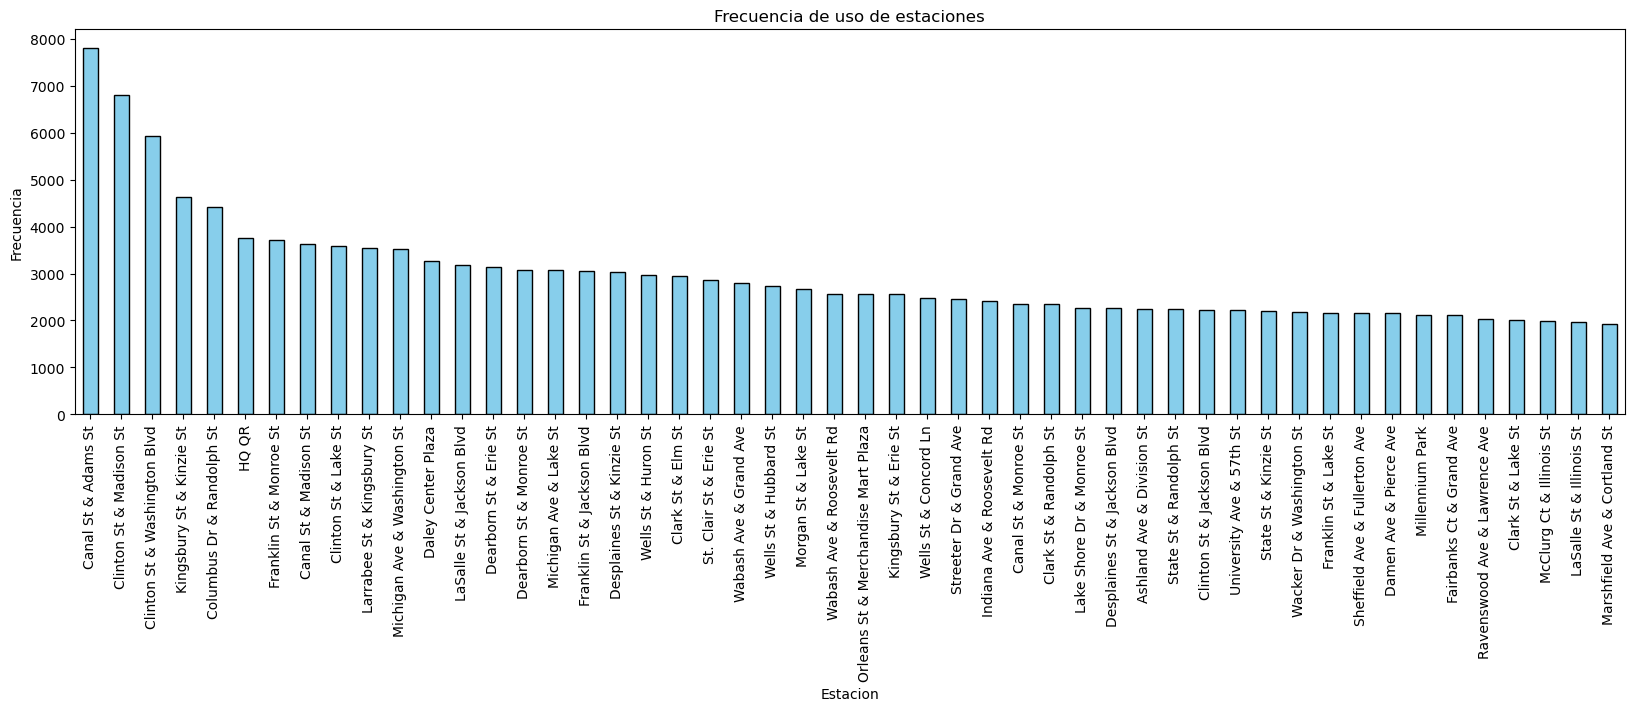

start_station_name
Canal St & Adams St                    7813
Clinton St & Madison St                6797
Clinton St & Washington Blvd           5941
Kingsbury St & Kinzie St               4626
Columbus Dr & Randolph St              4425
HQ QR                                  3767
Franklin St & Monroe St                3711
Canal St & Madison St                  3637
Clinton St & Lake St                   3580
Larrabee St & Kingsbury St             3550
Michigan Ave & Washington St           3533
Daley Center Plaza                     3269
LaSalle St & Jackson Blvd              3174
Dearborn St & Erie St                  3147
Dearborn St & Monroe St                3086
Michigan Ave & Lake St                 3084
Franklin St & Jackson Blvd             3060
Desplaines St & Kinzie St              3029
Wells St & Huron St                    2968
Clark St & Elm St                      2954
St. Clair St & Erie St                 2859
Wabash Ave & Grand Ave                 2808
Wells St & Hu

In [ ]:
plt.figure(figsize=(20, 5))
# mostrar las estaciones mas concurridas para iniciar el viaje
stations = data.start_station_name
conteo = stations.value_counts().head(50)
conteo.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Frecuencia de uso de estaciones donde se inician los rides")
plt.xlabel("Estacion")
plt.ylabel("Frecuencia")
plt.show()

conteo


In [37]:
"""
# solo fueron propositos de prueba
test = trafico_dias[0:10]
test[0] = None
test[1] = ''
test[2] = np.nan
test[3] = 'Juan'
print(test)

print("####### tipos de datos ########")
noValid = test.apply(lambda x: isinstance(x, float)) ## valida el tipo de dato
print(list(filter(lambda x: x is False, noValid))) ## obtiene los tipos de datos

# Datos de ejemplo
datos = [22, 87, 5, 43, 56, 73, 55, 54, 11, 20, 51, 5]

# Crear histograma
conteo, bins, patches = plt.hist(datos, bins=5, color="skyblue", edgecolor="black")

# Crear etiquetas personalizadas para cada bin
etiquetas = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]

# Colocar etiquetas en el eje X
plt.xticks([(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)], etiquetas)

plt.title("Histograma con etiquetas en bins")
plt.xlabel("Intervalos")
plt.ylabel("Frecuencia")
plt.show()



datos = np.array([2,3,4,5,5,4,5])

# Calcular histograma con NumPy
conteo, bins = np.histogram(datos, bins=4)

# Dibujar con Matplotlib
plt.hist(datos, bins=4, color="orange", edgecolor="black")

datos = pd.Series(["Gaby", "te amo", "Juan", "Gaby", "Juan", "Gaby"])
conteo = datos.value_counts()
conteo.plot(kind="bar", color="skyblue", edgecolor="black")


"""

'\n# solo fueron propositos de prueba\ntest = trafico_dias[0:10]\ntest[0] = None\ntest[1] = \'\'\ntest[2] = np.nan\ntest[3] = \'Juan\'\nprint(test)\n\nprint("####### tipos de datos ########")\nnoValid = test.apply(lambda x: isinstance(x, float)) ## valida el tipo de dato\nprint(list(filter(lambda x: x is False, noValid))) ## obtiene los tipos de datos\n\n# Datos de ejemplo\ndatos = [22, 87, 5, 43, 56, 73, 55, 54, 11, 20, 51, 5]\n\n# Crear histograma\nconteo, bins, patches = plt.hist(datos, bins=5, color="skyblue", edgecolor="black")\n\n# Crear etiquetas personalizadas para cada bin\netiquetas = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]\n\n# Colocar etiquetas en el eje X\nplt.xticks([(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)], etiquetas)\n\nplt.title("Histograma con etiquetas en bins")\nplt.xlabel("Intervalos")\nplt.ylabel("Frecuencia")\nplt.show()\n\n\n\ndatos = np.array([2,3,4,5,5,4,5])\n\n# Calcular histograma con NumPy\nconteo, bins = np.histogram(